In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [46]:
df = pd.read_csv(r"C:\Eni data\PYTHON\PYTHON CODES & PROJECTS\uber_ml_data.csv")
df.head()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,distance_km,hour of day,day of week,month,passenger_count,is_peak_hour,distance_bins,fare_amount
0,-73.999817,40.738354,-73.999512,40.723217,2,19,Thursday,5,1,1,short,7.5
1,-73.994355,40.728225,-73.994710,40.750325,2,20,Friday,7,1,1,short,7.7
2,-74.005043,40.740770,-73.962565,40.772647,5,21,Monday,8,1,1,medium,12.9
3,-73.976124,40.790844,-73.965316,40.803349,2,8,Friday,6,3,1,short,5.3
4,-73.925023,40.744085,-73.973082,40.761247,4,17,Thursday,8,5,1,medium,16.0


In [47]:
print(df.shape)

(172928, 12)


In [48]:
# distance = 0 km but fare > 0 we drop them They are bad data — a ride cannot 
# have zero distance and a non-zero fare. GPS failed to record the trip, but 
# the fare still got logged. Keeping them will confuse your model because it 
# learns "0km can cost $8" which is meaningless.

df = df[df['distance_km'] > 0]
print(df.shape)  # see how many rows remain

(172928, 12)


###  Route_cluster feature

In [49]:
# two rides can be identical in distance (say 3km) but one is JFK airport → Manhattan and 
# another is Brooklyn side street → next block. Fare will differ because of route demand, 
# traffic, and zone — distance_km can't capture that, but a cluster label can.
# Then add route_cluster as a feature in your model. 
# Try 10, 20, 30 clusters and see which gives best R² improvement.
from sklearn.cluster import KMeans

coords = df[['pickup_latitude', 'pickup_longitude',
             'dropoff_latitude', 'dropoff_longitude']]

# try 20 clusters — captures major NYC route zones
kmeans = KMeans(n_clusters=30, random_state=42, n_init=10)
df['route_cluster'] = kmeans.fit_predict(coords)

print("Cluster distribution:")
print(df['route_cluster'].value_counts().sort_index())

# drop raw GPS columns — done with them
df.drop(columns=['pickup_latitude', 'pickup_longitude',
                  'dropoff_latitude', 'dropoff_longitude'], inplace=True)

Cluster distribution:
route_cluster
0      9594
1        77
2         8
3      1817
4     11185
5         1
6      7924
7         1
8       342
9     13145
10     9879
11     3354
12        5
13     1453
14     8373
15    11080
16     5674
17        8
18    18550
19        3
20     7684
21      873
22    10127
23    10603
24     3855
25    17881
26     9751
27      478
28     2922
29     6281
Name: count, dtype: int64


### Encoding

In [50]:
# distance_bins → Label Encoding (short/medium/long has natural order)
le = LabelEncoder()
df['distance_bins_encoded'] = le.fit_transform(df['distance_bins'])
print("Distance bins mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# day of week → One-Hot Encoding (no natural order)
df = pd.get_dummies(df, columns=['day of week'], drop_first=True)

# drop original distance_bins column now that we encoded it
df.drop(columns=['distance_bins'], inplace=True)

print("\nColumns after encoding:")
print(df.columns.tolist())

Distance bins mapping: {'long': np.int64(0), 'medium': np.int64(1), 'short': np.int64(2)}

Columns after encoding:
['distance_km', 'hour of day', 'month', 'passenger_count', 'is_peak_hour', 'fare_amount', 'route_cluster', 'distance_bins_encoded', 'day of week_Monday', 'day of week_Saturday', 'day of week_Sunday', 'day of week_Thursday', 'day of week_Tuesday', 'day of week_Wednesday']


### Train test split

In [51]:
X = df.drop(columns=['fare_amount'])
y = df['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")

Train size : (138342, 13)
Test size  : (34586, 13)


### Scaling (only for Linear Regression)

In [52]:
# Tree models (RF, XGBoost) don't need scaling
# We keep a scaled version only for Linear Regression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# X_train and X_test (unscaled) → used for RF and XGBoost
# X_train_scaled and X_test_scaled → used for Linear Regression only

### Train All 3 Models

In [53]:
# ── Linear Regression ─────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
print("Linear Regression → done")

# ── Random Forest ─────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("Random Forest     → done")

# ── XGBoost ───────────────────────────────────────────────────────
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1,
                    random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
print("XGBoost           → done")

Linear Regression → done
Random Forest     → done
XGBoost           → done


### Cross Validation

In [54]:
# Cross validation on XGBoost (main model) — 5 fold
cv_scores = cross_val_score(xgb, X_train, y_train,
                             cv=5,
                             scoring='r2')

print(f"XGBoost CV R² scores : {cv_scores.round(4)}")
print(f"Mean R²              : {cv_scores.mean():.4f}")
print(f"Std                  : {cv_scores.std():.4f}")

XGBoost CV R² scores : [0.6249 0.6468 0.6358 0.6517 0.623 ]
Mean R²              : 0.6364
Std                  : 0.0114


### Evaluation Metrics

In [55]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"{'─'*40}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R²   : {r2:.4f}")

evaluate("Linear Regression", y_test, lr_preds)
evaluate("Random Forest",     y_test, rf_preds)
evaluate("XGBoost",           y_test, xgb_preds)


────────────────────────────────────────
  Linear Regression
────────────────────────────────────────
  MAE  : 1.9431
  RMSE : 3.2057
  R²   : 0.5904

────────────────────────────────────────
  Random Forest
────────────────────────────────────────
  MAE  : 2.0800
  RMSE : 3.4163
  R²   : 0.5348

────────────────────────────────────────
  XGBoost
────────────────────────────────────────
  MAE  : 1.8229
  RMSE : 3.0350
  R²   : 0.6329


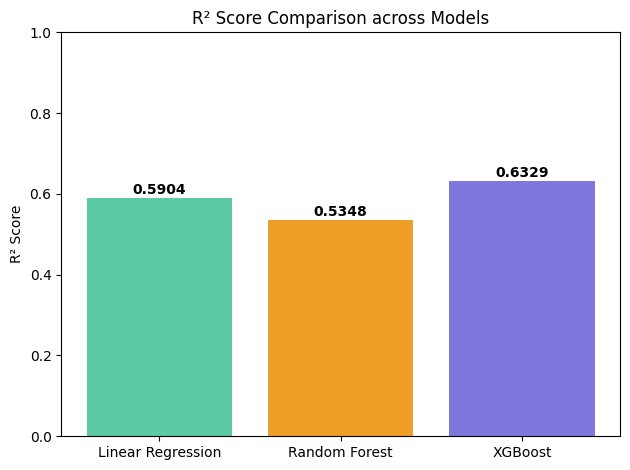

In [56]:
# ── Visual comparison ─────────────────────────────────────────────
models = ['Linear Regression', 'Random Forest', 'XGBoost']
r2_scores = [
    r2_score(y_test, lr_preds),
    r2_score(y_test, rf_preds),
    r2_score(y_test, xgb_preds)
]

plt.bar(models, r2_scores, color=['#5DCAA5', '#EF9F27', '#7F77DD'])
plt.title('R² Score Comparison across Models')
plt.ylabel('R² Score')
plt.ylim(0, 1)
for i, v in enumerate(r2_scores):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Importance (XGBoost)

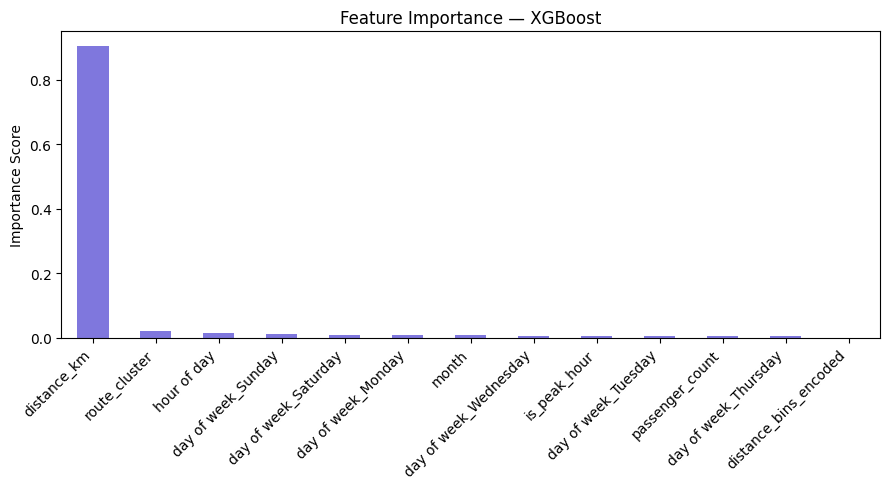


Top 3 features:
distance_km      0.904256
route_cluster    0.020446
hour of day      0.014208
dtype: float32


In [57]:
importance = pd.Series(xgb.feature_importances_,
                        index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importance.plot(kind='bar', color='#7F77DD')
plt.title('Feature Importance — XGBoost')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 3 features:")
print(importance.head(3))

###  Hyperparameter Tuning (RandomizedSearchCV on XGBoost)

In [58]:
from sklearn.model_selection import RandomizedSearchCV

# GridSearch is slow on large data → RandomizedSearch is faster
param_grid = {
    'n_estimators'    : [100, 200, 300],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'max_depth'       : [3, 5, 7],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator  = XGBRegressor(random_state=42, verbosity=0),
    param_distributions = param_grid,
    n_iter      = 20,       # tries 20 random combinations
    scoring     = 'r2',
    cv          = 3,
    random_state= 42,
    n_jobs      = -1        # uses all CPU cores
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print(f"Best CV R²     : {random_search.best_score_:.4f}")

# Evaluate tuned model
best_xgb       = random_search.best_estimator_
best_xgb_preds = best_xgb.predict(X_test)
evaluate("XGBoost (Tuned)", y_test, best_xgb_preds)

Best parameters: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Best CV R²     : 0.6367

────────────────────────────────────────
  XGBoost (Tuned)
────────────────────────────────────────
  MAE  : 1.8220
  RMSE : 3.0326
  R²   : 0.6334


### conclusion
Looking at the feature importance plot — distance_km dominates at ~0.90, route_cluster is second but distant at ~0.025, everything else (hour, day, passenger count, peak flag) is near zero. This confirms what the hypothesis tests already told us — distance drives fare, time and passenger count don't.

Conclusion — Uber Fare Prediction
Trained three regression models (Linear Regression, Random Forest, XGBoost) on 175K+ NYC Uber rides using trip-level and engineered features. XGBoost was the best performing model with MAE = 1.82, RMSE = 3.03, and R² = 0.63 after hyperparameter tuning and route clustering (n=30) via KMeans on GPS coordinates. Feature importance confirmed distance_km as the overwhelmingly dominant predictor (~90% importance), with route_cluster as a distant second — consistent with Kruskal-Wallis findings from hypothesis testing (η² = 0.55). All time-based features (peak hour, day of week, month) and passenger count contributed negligible predictive signal, aligning with A/B test results (p > 0.05). The R² ceiling of 0.63 is attributed to the absence of surge pricing data, weather, and traffic conditions — external variables not present in the dataset that likely explain the remaining 37% of fare variance.